In [67]:
import numpy as np
from scipy.interpolate import CubicSpline, make_smoothing_spline
import json 

In [54]:
import matplotlib.pyplot as plt
from matplotlib import rc
from typing import Dict, Tuple, Literal, List
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
import os

os.environ['PATH'] = f"/Library/TeX/texbin:{os.environ['PATH']}"
rc('text', usetex=True)
plt.rcParams['text.usetex'] = True
rc('font', **{'family': 'serif'})
plt.rcParams.update({'font.size': 20})

In [81]:
# Fit results for different truncations
fit_results = {eft_truncation: {mxx: [] for mxx in range(4, 11)} for eft_truncation in ["d6", "d6sq"]}

for eft_truncation in fit_results:
    with open(f"../../FitStats/Zprime/{eft_truncation}/C2JB.json") as file_:
        fit_info = json.load(file_)
    
    for benchmark in fit_info:
        fit_results[eft_truncation][benchmark["MXX"]].append(
            {
                "beta": benchmark["beta"], 
                "best-fit": benchmark["best-fit"],
                "lower-limit": benchmark["lower-limit"],
                "upper-limit": benchmark["upper-limit"]
            }
        ) 
    
    # Sort by beta
    for mxx, min_chi_sq in fit_results[eft_truncation].items():
        fit_results[eft_truncation][mxx] = sorted(min_chi_sq, key=lambda entry: entry["beta"])


In [93]:
vev = 0.246
aem_inv = 128.951
aem = 1/aem_inv
ee = np.sqrt(4 * np.pi *aem )
matching = {
    "d6": lambda beta, mxx: -0.5 * np.power(beta / mxx, 2),
    "d6sq": lambda beta, mxx: -0.5 * np.power(beta / mxx, 2) - 0.25 * np.power(vev, 2) * np.power(ee * beta / mxx, 4)
}

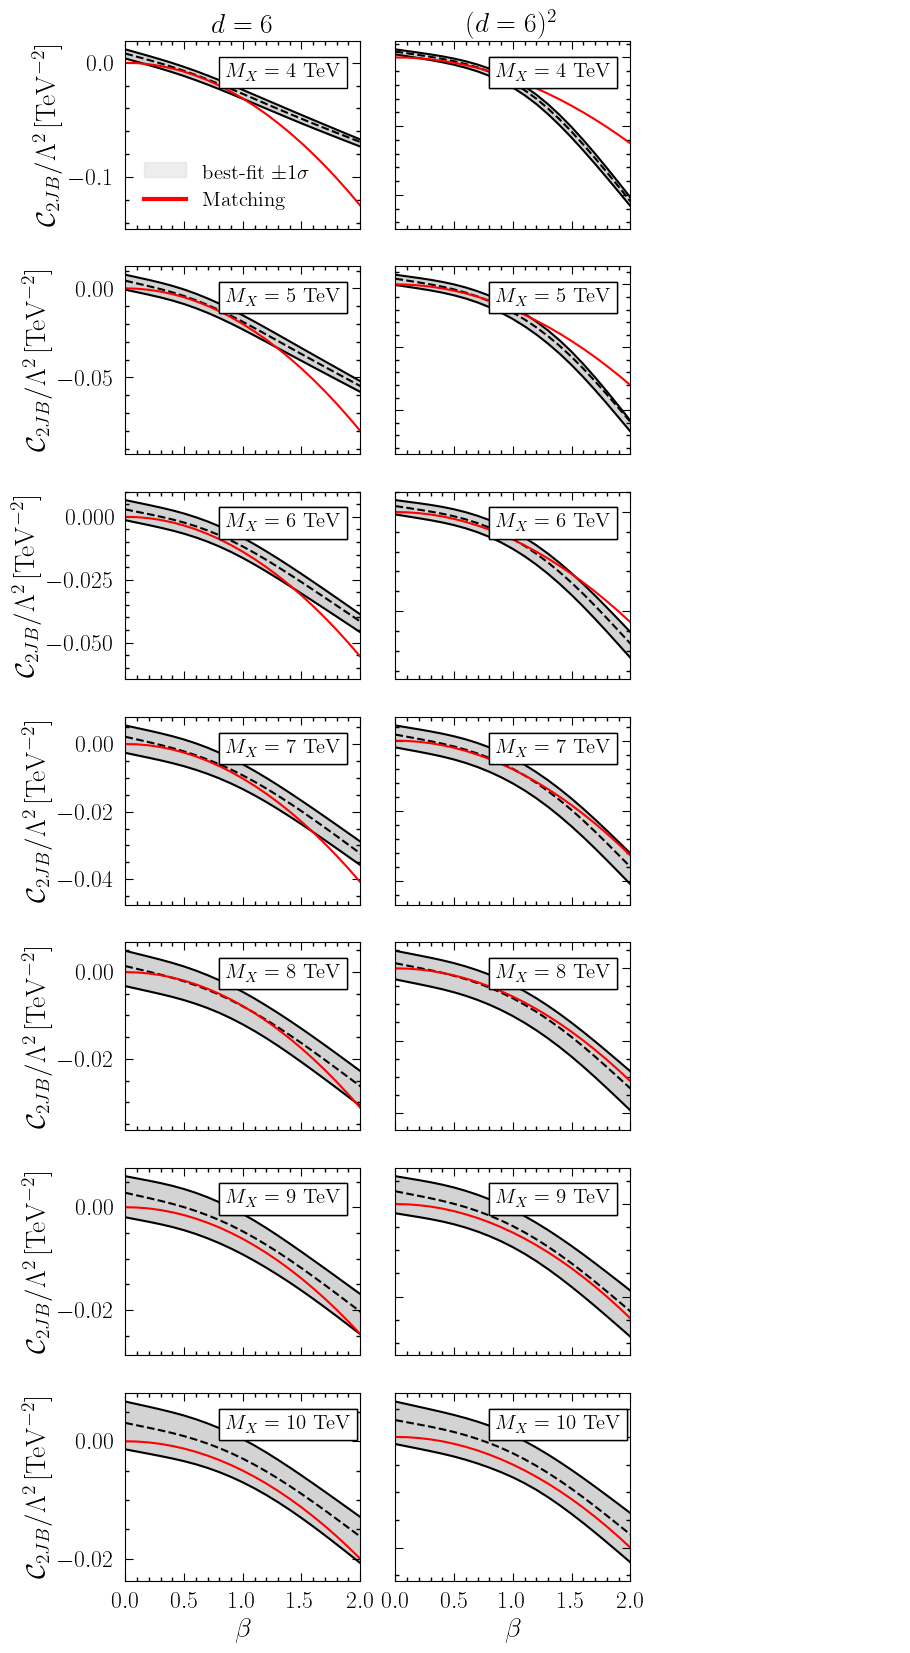

In [97]:
mxx_values = list(range(4, 11, 1))

fig, ax = plt.subplots(len(mxx_values), 3, figsize=(10, 20))
# spacing
plt.subplots_adjust(wspace=0.15, hspace=0.20)
plt.gca().set_aspect('equal')

for i in range(len(mxx_values)):
    ax[i, -1].axis("off")

# x-values
x_axis = np.arange(0, 2.2, 0.1)
ax[0, 0].set_title(r"$d=6$", size=20)
ax[0, 1].set_title(r"$(d=6)^2$", size=20)

plot_legs = [
    plt.Rectangle((0, 0), 0.2, 0.2, alpha=0.4, color="lightgray", label=r"best-fit $\pm 1\sigma$"),
    Line2D([0], [0], linestyle="solid", color="red", alpha=1, label=r"Matching", lw=3),
    # Line2D([0], [0], linestyle="dashed", color=colors["SM"], alpha=1, label=r"SM", lw=3),
]


# Loop over the masses (each row)
for index_row, mxx in enumerate(mxx_values):
    # Iterates over the EFT truncations (columns)
    for index_col, eft in enumerate(["d6", "d6sq"]):
        # Interpolation for the upper and lower limits
        beta_values = np.array([entry["beta"] for entry in fit_results[eft][mxx]])
        upper_limit = np.array([entry["upper-limit"] for entry in fit_results[eft][mxx]])
        lower_limit = np.array([entry["lower-limit"] for entry in fit_results[eft][mxx]])
        best_fit = np.array([entry["best-fit"] for entry in fit_results[eft][mxx]])
        
        # Interpolation
        upper_limit_func = make_smoothing_spline(beta_values, upper_limit, lam=0.02)
        lower_limit_func = make_smoothing_spline(beta_values, lower_limit, lam=0.02)
        bestfit_func = make_smoothing_spline(beta_values, best_fit, lam=0.02)
        
        ax[index_row, index_col].fill_between(
            x_axis, 
            lower_limit_func(x_axis),
            upper_limit_func(x_axis),
            color="lightgray"
        )
        
        ax[index_row, index_col].plot(x_axis, bestfit_func(x_axis), color="black", linestyle="dashed")
        ax[index_row, index_col].plot(x_axis, lower_limit_func(x_axis), color="black", linestyle="solid")
        ax[index_row, index_col].plot(x_axis, upper_limit_func(x_axis), color="black", linestyle="solid")
        
        # Matching 
        matching_results = np.array([matching[eft](val, mxx) for val in x_axis])
        ax[index_row, index_col].plot(x_axis, matching_results, color="red", linestyle="solid")
        
        ax[index_row, index_col].set_xlim((0, 2))
                
        # Ticks
        ax[index_row, index_col].xaxis.set_minor_locator(AutoMinorLocator())
        ax[index_row, index_col].yaxis.set_minor_locator(AutoMinorLocator())
        ax[index_row, index_col].tick_params(axis="both", which="minor", top=True, right=True, length=3, direction="in", width=1)
        ax[index_row, index_col].tick_params(axis="both", which="major", top=True, right=True, length=6, direction="in", labelsize=17, pad=8)
        
        ax[index_row, index_col].set_xticks(np.linspace(0, 2, 5))
        
        if index_row < len(mxx_values) - 1:
            ax[index_row, index_col].tick_params(axis="x", labelbottom=False)
        else:
            ax[index_row, index_col].set_xlabel(r"$\beta$")
            
        if index_col == 1:
            ax[index_row, index_col].tick_params(axis="y", labelleft=False)
        else:
            ax[index_row, index_col].set_ylabel(r"${\cal C}_{2JB}/\Lambda^2\, [\mathrm{TeV}^{-2}]$")

        leg_mxx = [Line2D([], [], linestyle='None', markersize=0, label=fr"$M_{{X}} = {mxx}$ TeV")]
        mxx_label = ax[index_row, index_col].legend(handles=leg_mxx, fancybox=False, frameon=True, framealpha=1, edgecolor="black", ncols=1, fontsize=15, loc=(0.4, 0.75), borderpad=0.3,  handlelength=0, handletextpad=0)
        ax[index_row, index_col].add_artist(mxx_label)
        
ax[0, 0].legend(handles=plot_legs, fancybox=True, frameon=False, framealpha=0.7, edgecolor="black", ncols=1, fontsize=15, loc="lower left", borderpad=0.4)
plt.savefig(f"../../Plots/C2JB-Zp.pdf", format="pdf", bbox_inches="tight", dpi=300)